<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Homeworks/Homework_2_Info_648_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#We need to import pandas
import pandas as pd

In [ ]:
#We need to read in our data to the active python session - we will read it directly into a data frame.
df = pd.read_csv('/content/cps_with_education.csv')

In [ ]:
five_num = {df["EARNWEEK2"].min(),
            df["EARNWEEK2"].quantile(0.25),
            df["EARNWEEK2"].median(),
            df["EARNWEEK2"].quantile(0.75),
            df["EARNWEEK2"].max()}
five_num

{0.0, np.float64(3840.0), 999999.99}

In [ ]:
df["EARNWEEK2"].describe(percentiles=[.25, .5, .75]).round(3)

,EARNWEEK2
count,5553935.000
mean,748326.966
std,433828.175
min,0.000
25%,3840.000
50%,999999.990
75%,999999.990
max,999999.990


The Tukey 5 summary reveals a skewed distribution that would be compressed at the top. The median 75th percentile and max are all the sam while the 25th percentile is much lower. This could be interpretted as many low values before a sharp jump into high identical values.

The standard deviation shows the spread around the mean as over 400k. This is the reflection of all of the points in the data set being high and extremely dispersed while the 5 summary points only show specific parts of the data set. The standard deviation is also showing that the distance between high points is large.

In [ ]:
df_college_grads = df[df['education']== "Bachelor's"].copy()

In [ ]:
df_college_grads.head(10)

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
7,7,2020,999,0.0,47,2,23,Bachelor's
14,14,2020,40,0.0,35,2,23,Bachelor's
25,25,2020,999,0.0,55,2,23,Bachelor's
43,43,2020,999,0.0,53,1,23,Bachelor's
44,44,2020,999,0.0,52,2,23,Bachelor's
46,46,2020,36,0.0,33,2,23,Bachelor's
47,47,2020,48,0.0,39,1,23,Bachelor's
60,60,2020,24,0.0,29,2,23,Bachelor's
68,68,2020,999,0.0,66,1,23,Bachelor's
93,93,2020,999,0.0,75,2,23,Bachelor's


In [ ]:
len(df_college_grads)

457734

In [ ]:
df_grad_students = df[df['education']== "Master's"].copy()

In [ ]:
df_grad_students.head(10)

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
15,15,2020,40,0.0,37,1,23,Master's
41,41,2020,999,0.0,36,1,23,Master's
82,82,2020,999,0.0,71,1,23,Master's
86,86,2020,40,0.0,34,1,23,Master's
88,88,2020,997,0.0,35,1,23,Master's
90,90,2020,10,0.0,66,2,23,Master's
91,91,2020,40,0.0,68,1,23,Master's
97,97,2020,999,0.0,69,2,23,Master's
100,100,2020,999,0.0,67,2,23,Master's
104,104,2020,997,0.0,58,2,23,Master's


In [ ]:
len(df_grad_students)

968670

For each of the above data sets I made a new set with the given name and added an equals filter to the education level. To learn the number of observations in the data frame I used the built in len function that tells me the number of rows in the given data sets.

For bachelor's students we have 457,734 and for Master's we have 968,670.

In [ ]:
df_college_grads.groupby("education")["EARNWEEK2"].agg(["median", "mean"]).reset_index()

,education,median,mean
0,Bachelor's,999999.99,730902.906416


In [ ]:
df_college_grads['EARNWEEK2'].std()

443328.42416785646

In [ ]:
df_grad_students.groupby("education")["EARNWEEK2"].agg(["median", "mean"]).reset_index()

,education,median,mean
0,Master's,999999.99,719205.452354


In [ ]:
df_grad_students['EARNWEEK2'].std()

449126.63706765516

In [ ]:
df_college_grads_clean=df_college_grads.copy()
df_college_grads_clean.loc[df_college_grads_clean['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
df_college_grads_clean.loc[df_college_grads_clean['EARNWEEK2']<1,'EARNWEEK2']=pd.NA

In [ ]:
df_college_grads_clean.groupby("education")["EARNWEEK2"].agg(["median", "mean"]).reset_index()

,education,median,mean
0,Bachelor's,962.0,1125.273351


In [ ]:
df_college_grads_clean['EARNWEEK2'].std()

871.7449697928213

In [ ]:
df_grad_students_clean=df_grad_students.copy()
df_grad_students_clean.loc[df_grad_students_clean['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
df_grad_students_clean.loc[df_grad_students_clean['EARNWEEK2']<1,'EARNWEEK2']=pd.NA

In [ ]:
df_grad_students_clean.groupby("education")["EARNWEEK2"].agg(["median", "mean"]).reset_index()

,education,median,mean
0,Master's,1350.0,1654.384494


In [ ]:
df_grad_students_clean['EARNWEEK2'].std()

1441.2471217236791

Both Bachelor's and Master's median weekly earnings are $999,999.99 which is a ceiling value when coding and not an actual answer, making the median unreilable for both groups. Looking at the mean we have some difference with Bachelor's having 730,902.9 and Master's having 719,205.5, giving the appearance that the Bachelor's make more. However the spread of the standard deviations are relativly close to one another meaning the IQR would be more robust since it is resisting the ceiling values. This data would most likely need to be cleaned up by removing top values and/or 0 values, in order to make the data more comparable.

Above I have also cleaned the data, after cleaning the data shows earnings fall fairly high to the center and the median sits in the upper end of the distribution. The IQR shows a wide range bewteen the 25th and 75th percentile, and the standard deviation is large indicating the earnings are dispersed far from the mean across the distrbution.

Compared to what we did in class the 5 number summary for UHRSWORKT shows a large compression in the middle. While the EARNWEEK2 shows a different story by collapsing the point to the raw earnings toward two extremes. The big difference is that by coding this we learned we would have to clean the data for the EARNWEEK2 otherwise it is not comparable to the data that was compressed from human behavior.

In [ ]:
df_corr = df_college_grads_clean.dropna(subset=['EARNWEEK2', 'UHRSWORKT'])
df_corr[['EARNWEEK2', 'UHRSWORKT']].corr()

,EARNWEEK2,UHRSWORKT
EARNWEEK2,1.000000,-0.007547
UHRSWORKT,-0.007547,1.000000


<Axes: xlabel='EARNWEEK2', ylabel='UHRSWORKT'>

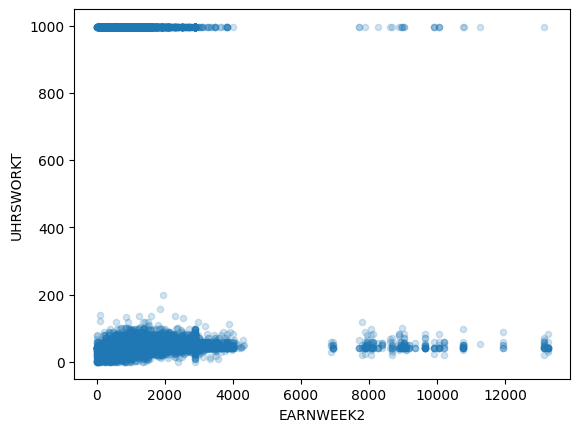

In [ ]:
df_corr.plot(kind="scatter", x="EARNWEEK2", y="UHRSWORKT", alpha=0.2)

In [ ]:
df_corr2 = df_grad_students_clean.dropna(subset=['EARNWEEK2', 'UHRSWORKT'])
df_corr2[['EARNWEEK2', 'UHRSWORKT']].corr()

,EARNWEEK2,UHRSWORKT
EARNWEEK2,1.000000,-0.002317
UHRSWORKT,-0.002317,1.000000


<Axes: xlabel='EARNWEEK2', ylabel='UHRSWORKT'>

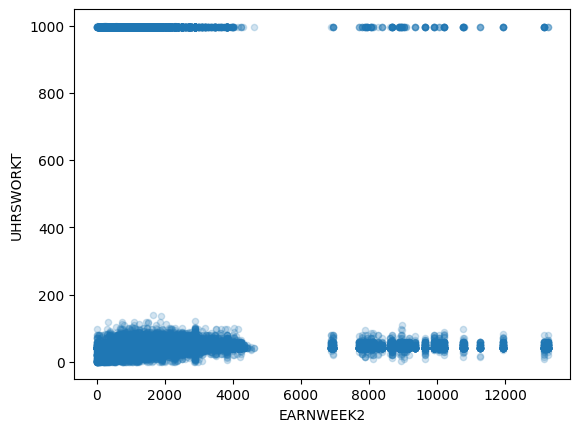

In [ ]:
df_corr2.plot(kind="scatter", x="EARNWEEK2", y="UHRSWORKT", alpha=0.2)

The correlation between EARNWEEK2 and UHRSWORKT is -0.007 and -0.002 for Bachelor's and Master's respectivly, which is basically 0. This tells us there is no linear relationship between the two. The scatterplot above confirms this because there is no trend shown. The scatterplot however does show that there is a number of observations with 1000 UHRSWORKT which could be a reason to clean the data and test again.

I think the most useful statistic was the median. Before cleaning any data both medians showed as 999,999 which flagged that the data had quality issues and needed to be cleaned. After cleaning the median clearly showed that Bachelor's earners had about 962/week while Master's has 1350/week, demonstrating a meaningful gap. The other statistics were not as useful since the mean was distored showing Bachelor's making more and the correlation was virtually 0 for both giving no information to futher explain the data.